In [1]:
from PIL import Image
import cv2
import matplotlib.pyplot as plt
import numpy as np
import sys
from skimage import io
from skimage.color import rgb2gray
from skimage.filters import gaussian
from skimage.segmentation import active_contour

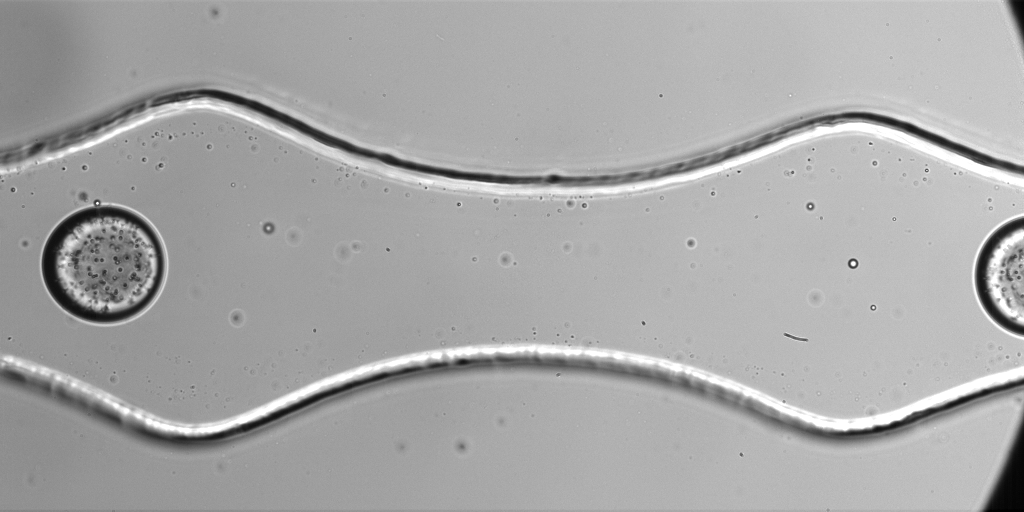

In [4]:
image_path_firstframe = '/Volumes/Elements/Rheoflu/Luca/Constrict_5/Constrict_5000001.tif'
img1 = Image.open(image_path_firstframe)
img1

# 1) **Edge finding**

We find the edge using active_contour.

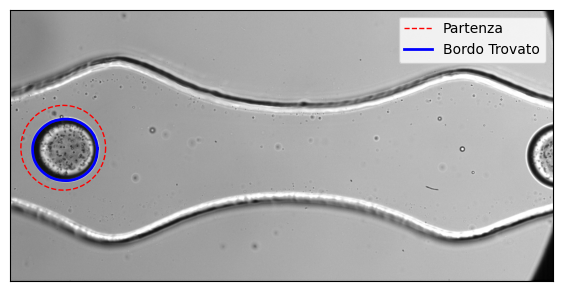

In [5]:
img = cv2.imread(image_path_firstframe) #converto in array

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (25, 25), 0)

y_centro = 260 # --- CERCHIO INIZIALE) ---
x_centro = 100
raggio = 80

# Crea 400 punti matematici per disegnare il cerchio
s = np.linspace(0, 2 * np.pi, 400)
y = y_centro + raggio * np.sin(s)
x = x_centro + raggio * np.cos(s)

# Unisci le coordinate in un array [riga, colonna]
init = np.array([y, x]).T 

# --- 3. APPLICAZIONE DEL CONTORNO ATTIVO ---
snake = active_contour(
    blurred, 
    init, 
    alpha=0.25,  # Elasticità: spinge la curva a contrarsi (valori tipici: 0.01 - 0.1)
    beta=30,      # Rigidità: mantiene la curva morbida e senza spigoli (valori tipici: 1 - 100)
    w_edge=9.0,   # Attrazione per i bordi: 1.0 significa che cerca bordi netti
    w_line=0.0,   # Settato a 0 perché cerchiamo un "bordo" (cambio di colore), non una linea
    boundary_condition='periodic' # FONDAMENTALE: dice che la curva è chiusa ad anello!
)

# --- 4. VISUALIZZAZIONE DEL RISULTATO ---
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(img, cmap=plt.cm.gray)

# Disegna la curva di partenza (rossa tratteggiata)
ax.plot(init[:, 1], init[:, 0], '--r', lw=1, label="Partenza")

# Disegna il risultato finale (blu continua)
ax.plot(snake[:, 1], snake[:, 0], '-b', lw=2, label="Bordo Trovato")

ax.set_xticks([]), ax.set_yticks([]) # Nasconde i numeri sugli assi
ax.legend()
plt.show()